# MLForecast Adapter — AirPassengers Example

This notebook shows how to use `MLForecastAdapter` with the classic
AirPassengers dataset (144 monthly observations, 1949–1960).

Unlike `StatsForecastAdapter`, the MLForecast adapter wraps **point**
forecasters only — `conformal-ts` produces its own intervals from those
point forecasts, so MLForecast configurations that produce intervals
natively (`prediction_intervals=...`) are rejected at construction.

We demonstrate:
1. Fitting an MLForecast pipeline (lag features + target transform) and creating the adapter
2. Point forecast
3. Cross-validation for conformal calibration
4. Split conformal prediction with calibrated intervals
5. v0.1 scope notes for MLForecast users
6. Refitting on extended data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlforecast import MLForecast
from mlforecast.lag_transforms import ExpandingMean, RollingMean
from mlforecast.target_transforms import Differences
from sklearn.linear_model import Ridge

from conformal_ts.adapters.mlforecast import MLForecastAdapter
from conformal_ts.methods.split import SplitConformal

## 1. Load data and fit the model

AirPassengers uses month-start timestamps, so `freq="MS"`. We fit a
`Ridge` regressor on engineered features:

* **Lags** `[1, 2, 3, 12]` — recent observations and a yearly seasonal lag.
* **Lag transforms** — expanding mean of the previous step and a rolling mean over the last six months at lag 12, to give the linear model some smoothed signal to lean on.
* **Target transform** `Differences([12])` — yearly differencing to remove the seasonal level shift before the regressor sees it. The inverse transform is applied automatically at prediction time.

In [4]:
HORIZON = 12
FREQ = "MS"

df = pd.read_csv(
    "https://datasets-nixtla.s3.amazonaws.com/air-passengers.csv",
    parse_dates=["ds"],
)
df["unique_id"] = df["unique_id"].astype(str)

print(f"Shape: {df.shape}")
print(f"Date range: {df['ds'].min()} to {df['ds'].max()}")
df.head()

Shape: (144, 3)
Date range: 1949-01-01 00:00:00 to 1960-12-01 00:00:00


,unique_id,ds,y
0,AirPassengers,1949-01-01,112
1,AirPassengers,1949-02-01,118
2,AirPassengers,1949-03-01,132
3,AirPassengers,1949-04-01,129
4,AirPassengers,1949-05-01,121


In [5]:
mlf = MLForecast(
    models={"Ridge": Ridge()},
    freq=FREQ,
    lags=[1, 2, 3, 12],
    lag_transforms={
        1: [ExpandingMean()],
        12: [RollingMean(window_size=6)],
    },
    target_transforms=[Differences([12])],
)
mlf.fit(df)

adapter = MLForecastAdapter(
    mlf=mlf,
    train_df=df,
    horizon=HORIZON,
    freq=FREQ,
    model_name="Ridge",
)

print(f"Adapter: n_series={adapter.n_series}, horizon={adapter.horizon}")
print(f"Common range: {adapter._common_start} to {adapter._common_end}")

Adapter: n_series=1, horizon=12
Common range: 1949-01-01 00:00:00 to 1960-12-01 00:00:00


## 2. Point forecast

`predict` returns shape `(n_series, 1, horizon)` — here `(1, 1, 12)`.
Lag and target transforms are handled inside MLForecast; the adapter
only ever sees panel arrays.

In [6]:
full_history = adapter._df_to_panel(df, "y")  # (1, 144)
forecast = adapter.predict(full_history)

print(f"Forecast shape: {forecast.shape}")
print(f"Next 12 months: {forecast[0, 0].round(1)}")

Forecast shape: (1, 1, 12)
Next 12 months: [442.  417.2 447.1 489.6 501.3 564.7 651.4 635.7 537.  489.8 419.5 462.7]


## 3. Cross-validation for conformal calibration

We use the adapter's built-in cross-validation to generate calibration
data — 24 rolling windows stepped by 1 month. This produces matched
`(predictions, truths)` arrays that `SplitConformal.calibrate` expects.

MLForecast's `cross_validation(refit=False)` trains the model once on
data up to the first cutoff and reuses it for every window; pass
`refit=True` to retrain at each step.

In [7]:
N_WINDOWS = 24
STEP_SIZE = 1

cv_preds, cv_truths = adapter.cross_validate(n_windows=N_WINDOWS, step_size=STEP_SIZE, refit=False)

print(f"CV predictions shape: {cv_preds.shape}")  # (1, 24, 12)
print(f"CV truths shape:      {cv_truths.shape}")

CV predictions shape: (1, 24, 12)
CV truths shape:      (1, 24, 12)


## 4. Split conformal prediction

We can calibrate `SplitConformal` directly on the adapter — passing
`n_windows` (and optionally `step_size` / `refit`) makes the method
dispatch to `forecaster.cross_validate(...)` under the hood, which is
**one** native MLForecast call. The slower fallback path (one
`predict_batch` call per window) is reserved for adapters that don't
implement `SupportsCrossValidation`.

In [8]:
ALPHA = 0.1  # 90% prediction intervals

method = SplitConformal(adapter, alpha=ALPHA)
cal_result = method.calibrate(n_windows=N_WINDOWS, step_size=STEP_SIZE)

print(f"Calibration samples: {cal_result.n_calibration_samples}")
print(f"Score quantile shape: {cal_result.score_quantile.shape}")
print(f"Score quantile per horizon step:\n{cal_result.score_quantile[0].round(1)}")

Calibration samples: 24
Score quantile shape: (1, 12)
Score quantile per horizon step:
[20.5 28.3 36.5 36.6 34.1 36.4 36.3 36.  34.6 35.8 35.4 30. ]


### What is the score quantile?

The **score quantile** is the core output of conformal calibration. Here's how it works:

1. For each of the 24 cross-validation windows, the model forecasts 12 months ahead and we compute the **absolute residual** `|truth - prediction|` at every horizon step.
2. We then take the empirical quantile of these residuals at level `ceil((1 - alpha) * (n + 1)) / n` — a finite-sample-corrected version of the `(1 - alpha)` quantile. This is computed **independently for each horizon step**.
3. The result is a vector of 12 values (one per horizon step). Each value is the threshold below which ~90% of the calibration residuals fell at that step.

The prediction interval at each horizon step `h` is then simply:

    [forecast(h) - q(h),  forecast(h) + q(h)]

The score quantile typically grows with the horizon, reflecting the natural increase in forecast uncertainty further into the future. The conformal method learns this from the calibration residuals without any distributional assumptions about the model.

In [9]:
# Produce a conformal prediction on the full history
result = method.predict(full_history)

print(f"Point forecast shape: {result.point.shape}")
print(f"Interval shape:       {result.interval.shape}")
print(f"Alpha:                {result.alpha}")
print()

# Display as a table
forecast_dates = pd.date_range(start=adapter._common_end, periods=HORIZON + 1, freq=FREQ)[1:]

summary = pd.DataFrame(
    {
        "date": forecast_dates,
        "lower_90": result.interval[0, 0, :, 0].round(1),
        "point": result.point[0, 0].round(1),
        "upper_90": result.interval[0, 0, :, 1].round(1),
    }
)
summary["width"] = (summary["upper_90"] - summary["lower_90"]).round(1)
summary

Point forecast shape: (1, 1, 12)
Interval shape:       (1, 1, 12, 2)
Alpha:                0.1



,date,lower_90,point,upper_90,width
0,1961-01-01,421.5,442.0,462.6,41.1
1,1961-02-01,389.0,417.2,445.5,56.5
2,1961-03-01,410.6,447.1,483.6,73.0
3,1961-04-01,453.0,489.6,526.1,73.1
4,1961-05-01,467.2,501.3,535.4,68.2
5,1961-06-01,528.3,564.7,601.0,72.7
6,1961-07-01,615.1,651.4,687.7,72.6
7,1961-08-01,599.7,635.7,671.7,72.0
8,1961-09-01,502.4,537.0,571.6,69.2
9,1961-10-01,454.0,489.8,525.7,71.7


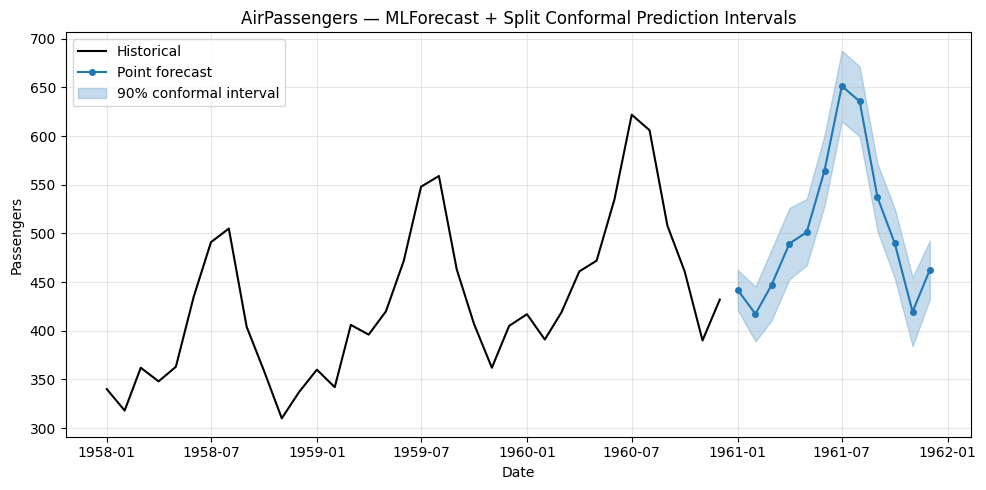

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

# Plot historical data
hist_dates = df["ds"].values
hist_values = full_history[0]
ax.plot(hist_dates[-36:], hist_values[-36:], color="black", label="Historical")

# Plot forecast and conformal interval
ax.plot(
    forecast_dates,
    result.point[0, 0],
    color="tab:blue",
    marker="o",
    markersize=4,
    label="Point forecast",
)
ax.fill_between(
    forecast_dates,
    result.interval[0, 0, :, 0],
    result.interval[0, 0, :, 1],
    alpha=0.25,
    color="tab:blue",
    label=f"{1 - ALPHA:.0%} conformal interval",
)

ax.set_title("AirPassengers — MLForecast + Split Conformal Prediction Intervals")
ax.set_xlabel("Date")
ax.set_ylabel("Passengers")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 5. v0.1 scope notes for MLForecast users

Unlike `StatsForecastAdapter`, the MLForecast adapter does **not**
implement `SupportsQuantiles`: most sklearn-style regressors don't
expose calibrated quantiles, and CQR-family methods are out of scope
for v0.1. Quantile-based conformal methods will not accept this adapter.

The adapter also rejects three MLForecast configurations at construction
time, all to keep responsibility for uncertainty quantification on the
conformal side:

* `prediction_intervals=PredictionIntervals(...)` — MLForecast's native
  conformal-distribution intervals would compete with `conformal-ts`'s
  own calibration. Refit without this argument.
* `static_features=[...]` — covariates aren't supported in v0.1.
* `weight_col="..."` — sample weights aren't supported in v0.1.

Lag features, lag transforms, date features, and target transforms
(like the `Differences([12])` used above) are core MLForecast usage
and pass through transparently.

The cell below demonstrates the rejection path for `prediction_intervals`.

In [11]:
from mlforecast.utils import PredictionIntervals

mlf_with_intervals = MLForecast(
    models={"Ridge": Ridge()},
    freq=FREQ,
    lags=[1, 2, 3, 12],
)
mlf_with_intervals.fit(
    df,
    prediction_intervals=PredictionIntervals(
        n_windows=2, h=HORIZON, method="conformal_distribution"
    ),
)

try:
    MLForecastAdapter(
        mlf=mlf_with_intervals,
        train_df=df,
        horizon=HORIZON,
        freq=FREQ,
        model_name="Ridge",
    )
except ValueError as e:
    print(f"Rejected at construction: {e}")

Rejected at construction: MLForecast was fit with prediction_intervals. conformal-ts produces its own intervals from point forecasts — refit with mlf.fit(df) without the prediction_intervals argument.


## 6. Refit on extended data

Simulating the arrival of 12 new months of data. After `refit`, the
adapter's end timestamp advances and forecasts anchor at the new end.

In [12]:
print(f"End before refit: {adapter._common_end}")

# Simulate 12 new observations (repeat the last year with some noise)
rng = np.random.default_rng(42)
last_year = full_history[:, -12:]
new_obs = last_year * (1 + 0.05 * rng.standard_normal(last_year.shape))
extended_history = np.concatenate([full_history, new_obs], axis=1)

print(f"Original history: {full_history.shape[1]} months")
print(f"Extended history: {extended_history.shape[1]} months")

adapter.refit(extended_history)
print(f"End after refit:  {adapter._common_end}")

# Forecast from the new end
new_forecast = adapter.predict(extended_history)
print(f"\nForecast from extended data (first 3 months): {new_forecast[0, 0, :3].round(1)}")

End before refit: 1960-12-01 00:00:00
Original history: 144 months
Extended history: 156 months
End after refit:  1961-12-01 00:00:00

Forecast from extended data (first 3 months): [441.  397.6 463.9]
